# External Validation & Cross-Dataset Generalization Study

## Deteksi ICH: Generalisasi CQ500 → RSNA (Domain Shift Analysis)

**Desain Studi:**
- **Dataset Training:** CQ500 (rumah sakit India, CT non-kontras)
- **Dataset Validasi Eksternal:** RSNA Intracranial Hemorrhage Detection Challenge
- **Tujuan:** Mengukur seberapa baik model yang dilatih pada CQ500 dapat menggeneralisasi ke dataset RSNA yang berasal dari distribusi berbeda (*domain shift*).

## 1. Import Library

Mengimpor semua library yang dibutuhkan: PyTorch, NumPy, Pandas, pydicom, scikit-learn, dan matplotlib.

In [2]:
import os
import random
import warnings
import numpy as np
import pandas as pd
import pydicom
from collections import defaultdict

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

from sklearn.metrics import (
    roc_auc_score, roc_curve, confusion_matrix,
    accuracy_score, precision_recall_curve, average_precision_score
)

# =====================
# Suppress RSNA anonymized UID warnings from pydicom
# RSNA uses anonymized UIDs (e.g. "ID_3f66faf698") which are not valid DICOM UIDs,
# but they work fine for our purposes. This suppresses the VR validation warnings.
# =====================
warnings.filterwarnings("ignore", message="Invalid value for VR UI")
import matplotlib.pyplot as plt

## 2. Load Dataset RSNA

Memuat file label RSNA (`stage_2_train.csv`) dan membangun DataFrame study-level dengan label ICH per studi.

In [3]:
# =====================
# Load RSNA Intracranial Hemorrhage Detection Dataset
# =====================
RSNA_ROOT = "/kaggle/input/competitions/rsna-intracranial-hemorrhage-detection/rsna-intracranial-hemorrhage-detection"
RSNA_DICOM_DIR = os.path.join(RSNA_ROOT, "stage_2_train")
RSNA_CSV = os.path.join(RSNA_ROOT, "stage_2_train.csv")  # labels CSV

# Load the RSNA labels CSV
# Format: ID = "ID_<hash>_<subtype>", Label = 0 or 1
# Subtypes: epidural, intraparenchymal, intraventricular, subarachnoid, subdural, any
df_rsna = pd.read_csv(RSNA_CSV)
print(f"RSNA CSV shape: {df_rsna.shape}")
print(df_rsna.head(12))
print(f"\nColumns: {list(df_rsna.columns)}")

# Parse: "ID_<hash>_<subtype>" → image_id = "ID_<hash>", subtype = "<subtype>"
# The ID column always starts with "ID_", then a hex hash, then "_<subtype>"
# Subtypes are single words: epidural, intraparenchymal, intraventricular, subarachnoid, subdural, any
def parse_rsna_id(id_str):
    """Parse RSNA ID column into (image_id, subtype).
    Example: 'ID_12cadc6af_epidural' → ('ID_12cadc6af', 'epidural')
    """
    # Split from the right — subtype is always the last token
    parts = id_str.rsplit("_", 1)
    image_id = parts[0]   # e.g. "ID_12cadc6af"
    subtype = parts[1]    # e.g. "epidural"
    return image_id, subtype

parsed = df_rsna["ID"].apply(parse_rsna_id)
df_rsna["image_id"] = parsed.apply(lambda x: x[0])
df_rsna["subtype"] = parsed.apply(lambda x: x[1])

print(f"\nUnique subtypes: {df_rsna['subtype'].unique()}")
print(f"Sample image_ids: {df_rsna['image_id'].unique()[:5]}")

# Pivot to get one row per image with all subtype labels
df_pivot = df_rsna.pivot_table(
    index="image_id", columns="subtype", values="Label", aggfunc="first"
).reset_index()

print(f"\nPivot table shape: {df_pivot.shape}")
print(f"Columns: {list(df_pivot.columns)}")
print(df_pivot.head())

# Map experiment names to RSNA subtype columns
# Subtypes in the CSV are: any, epidural, intraparenchymal, intraventricular, subarachnoid, subdural
SUBTYPE_MAP = {
    "any_ich": "any",
    "iph": "intraparenchymal",
    "sdh": "subdural",
    "sah": "subarachnoid",
    "edh": "epidural",
    "ivh": "intraventricular",
}

print("\nRSNA dataset loaded successfully.")
print(f"Total unique images: {df_pivot.shape[0]}")

RSNA CSV shape: (4516842, 2)
                               ID  Label
0           ID_12cadc6af_epidural      0
1   ID_12cadc6af_intraparenchymal      0
2   ID_12cadc6af_intraventricular      0
3       ID_12cadc6af_subarachnoid      0
4           ID_12cadc6af_subdural      0
5                ID_12cadc6af_any      0
6           ID_38fd7baa0_epidural      0
7   ID_38fd7baa0_intraparenchymal      0
8   ID_38fd7baa0_intraventricular      0
9       ID_38fd7baa0_subarachnoid      0
10          ID_38fd7baa0_subdural      0
11               ID_38fd7baa0_any      0

Columns: ['ID', 'Label']

Unique subtypes: ['epidural' 'intraparenchymal' 'intraventricular' 'subarachnoid'
 'subdural' 'any']
Sample image_ids: ['ID_12cadc6af' 'ID_38fd7baa0' 'ID_6c5d82413' 'ID_aec8e68b3'
 'ID_4d9209c7c']

Pivot table shape: (752803, 7)
Columns: ['image_id', 'any', 'epidural', 'intraparenchymal', 'intraventricular', 'subarachnoid', 'subdural']
subtype      image_id  any  epidural  intraparenchymal  intraventricular 

## 3. Konfigurasi & Reproducibility

Menetapkan seed, memilih eksperimen, mendefinisikan backbone dan hyperparameter utama, serta membuat split train/val/test untuk dataset RSNA.

In [4]:
# =====================
# CONFIG — Change EXPERIMENT_NAME to run different experiments
# =====================
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# RSNA DICOM directory (stage_2_train has the labeled images)
RSNA_DICOM_DIR = "/kaggle/input/competitions/rsna-intracranial-hemorrhage-detection/rsna-intracranial-hemorrhage-detection/stage_2_train"

BATCH_SIZE = 32

# =====================
# EXPERIMENT — Maps to RSNA subtypes
# =====================
EXPERIMENT_NAME = "any_ich"   # <-- CHANGE THIS to: "any_ich", "iph", "sdh", "sah", "edh", "ivh"

# =====================
# BACKBONES — Compare all backbones on the chosen experiment
# =====================
BACKBONE_NAMES = ["convnext_tiny", "resnet50", "efficientnet_b0"]

# =====================
# SAMPLE SIZE — Justifikasi Saintifik
# Berdasarkan Hanley & McNeil (1982): untuk estimasi AUC dengan CI 95%
# lebar ≤0.10 pada AUC ~0.85, dibutuhkan minimum 100 kasus positif.
# Kami menargetkan 150 studi positif sebagai safety margin (1.5x minimum).
#
# Karena ini adalah External Validation (bukan training), seluruh data
# digunakan sebagai test set — tidak ada split train/val.
# Ref: Collins & Moons (2019), Lancet: "external validation should use
#      all available independent data as a single test set."
#
# Kalkulasi:
#   - Target positif  : 150 studi
#   - Prevalensi RSNA : ~14% (study-level, any ICH)
#   - Total studi min : 150 / 0.14 ≈ 1.071 studi
#   - Rata-rata slice : ~35 slice/studi (RSNA)
#   - Target slice    : 1.071 × 35 × 1.5 (safety) ≈ 56.000 slice
# =====================
PREVALENCE_RSNA_APPROX  = 0.14   # prevalensi studi positif RSNA any_ich
N_POSITIVE_STUDIES_MIN  = 150    # Hanley & McNeil criterion + safety margin
AVG_SLICES_PER_STUDY    = 35     # rata-rata slice per studi RSNA
SAFETY_FACTOR           = 1.5    # buffer untuk variabilitas sampling

N_STUDIES_REQUIRED = int(N_POSITIVE_STUDIES_MIN / PREVALENCE_RSNA_APPROX)
N_SLICES_TARGET    = int(N_STUDIES_REQUIRED * AVG_SLICES_PER_STUDY * SAFETY_FACTOR)

print(f"Sample size calculation (Hanley & McNeil 1982):")
print(f"  Target positive studies : {N_POSITIVE_STUDIES_MIN}")
print(f"  Required total studies  : {N_STUDIES_REQUIRED}")
print(f"  N_SLICES_TARGET         : {N_SLICES_TARGET:,}")

# =====================
# RSNA metadata: Extract StudyInstanceUID for patient-level grouping
# =====================
print("\nReading DICOM metadata to extract StudyInstanceUID...")

rsna_subtype_col = SUBTYPE_MAP[EXPERIMENT_NAME]

# Get labels for the chosen experiment
df_experiment = df_pivot[["image_id", rsna_subtype_col]].copy()
df_experiment.columns = ["image_id", "label_prob"]
df_experiment["label"] = (df_experiment["label_prob"] >= 0.5).astype(int)

# Check which DICOM files actually exist
print("Checking available DICOM files...")
available_ids = set()
for f in os.listdir(RSNA_DICOM_DIR):
    if f.endswith(".dcm"):
        available_ids.add(f.replace(".dcm", ""))
print(f"Available DICOM files: {len(available_ids):,}")

df_experiment = df_experiment[df_experiment["image_id"].isin(available_ids)].reset_index(drop=True)
print(f"Slices with labels + DICOM files: {len(df_experiment):,}")

# =====================
# Stratified sampling pada level SLICE
# Pertahankan proporsi asli RSNA (bukan prevalence-matched)
# agar hasil evaluasi mencerminkan distribusi klinis nyata
# =====================
df_pos = df_experiment[df_experiment["label"] == 1]
df_neg = df_experiment[df_experiment["label"] == 0]

pos_ratio   = len(df_pos) / len(df_experiment)
n_pos_sample = int(N_SLICES_TARGET * pos_ratio)
n_neg_sample = N_SLICES_TARGET - n_pos_sample

df_pos_sample = df_pos.sample(n=min(n_pos_sample, len(df_pos)), random_state=SEED)
df_neg_sample = df_neg.sample(n=min(n_neg_sample, len(df_neg)), random_state=SEED)
df_sampled    = pd.concat([df_pos_sample, df_neg_sample]).sample(frac=1, random_state=SEED).reset_index(drop=True)

print(f"\nSampled {len(df_sampled):,} slices for metadata extraction...")
print(f"  Positive slices: {int(df_sampled['label'].sum()):,}")
print(f"  Negative slices: {int(len(df_sampled) - df_sampled['label'].sum()):,}")

# =====================
# Baca StudyInstanceUID dari DICOM header
# =====================
from tqdm import tqdm

study_uids    = []
valid_indices = []

for idx, row in tqdm(df_sampled.iterrows(), total=len(df_sampled), desc="Reading DICOM metadata"):
    dcm_path = os.path.join(RSNA_DICOM_DIR, f"{row['image_id']}.dcm")
    try:
        ds        = pydicom.dcmread(dcm_path, stop_before_pixels=True)
        study_uid = str(getattr(ds, "StudyInstanceUID", "unknown"))
        study_uids.append(study_uid)
        valid_indices.append(idx)
    except Exception:
        study_uids.append(None)
        valid_indices.append(idx)

df_sampled            = df_sampled.loc[valid_indices].copy()
df_sampled["study_id"] = study_uids
df_sampled            = df_sampled[df_sampled["study_id"].notna()].reset_index(drop=True)

# =====================
# Patient-level label: positif jika ada slice positif dalam studi
# =====================
study_labels          = df_sampled.groupby("study_id")["label"].max().reset_index()
study_labels.columns  = ["study_id", "study_label"]

n_studies     = len(study_labels)
n_pos_studies = int(study_labels["study_label"].sum())
n_neg_studies = n_studies - n_pos_studies

print(f"\n{'='*60}")
print(f"  RSNA Dataset — Patient-Level Summary")
print(f"{'='*60}")
print(f"  Total slices          : {len(df_sampled):,}")
print(f"  Total unique studies  : {n_studies:,}")
print(f"  Positive studies      : {n_pos_studies} ({'✓ SUFFICIENT' if n_pos_studies >= N_POSITIVE_STUDIES_MIN else '✗ BELOW TARGET — increase N_SLICES_TARGET'})")
print(f"  Negative studies      : {n_neg_studies}")
print(f"  Avg slices/study      : {len(df_sampled) / n_studies:.1f}")

# Peringatan jika target tidak tercapai
if n_pos_studies < N_POSITIVE_STUDIES_MIN:
    print(f"\n⚠ WARNING: Hanya {n_pos_studies} studi positif (target: {N_POSITIVE_STUDIES_MIN}).")
    print(f"   Pertimbangkan menaikkan N_SLICES_TARGET atau SAFETY_FACTOR.")

# =====================
# External Validation: SEMUA data sebagai test set
# Ref: Collins & Moons (2019) — external validation tidak memerlukan
# train/val split karena model sudah dilatih di dataset lain (CQ500)
# =====================
splits = {
    EXPERIMENT_NAME: {
        "train": pd.DataFrame(columns=df_sampled.columns),  # kosong — tidak dipakai
        "val":   pd.DataFrame(columns=df_sampled.columns),  # kosong — tidak dipakai
        "test":  df_sampled,                                  # seluruh data = test set
    }
}

print(f"\n{'='*60}")
print(f"  RSNA External Validation Set")
print(f"{'='*60}")
print(f"  Design    : External validation (Collins & Moons 2019)")
print(f"  Criterion : Hanley & McNeil (1982) — min {N_POSITIVE_STUDIES_MIN} positive studies")
print(f"  Device    : {DEVICE}")
print(f"  Experiment: {EXPERIMENT_NAME} (RSNA subtype: '{rsna_subtype_col}')")
print(f"  Backbones : {BACKBONE_NAMES}")
n_test_studies = df_sampled["study_id"].nunique()
n_test_pos     = int(df_sampled.groupby("study_id")["label"].max().sum())
print(f"  Test set  : {n_test_studies} studies | {n_test_pos} pos / {n_test_studies - n_test_pos} neg ({100*n_test_pos/n_test_studies:.1f}% prevalence)")
print(f"{'='*60}")


Sample size calculation (Hanley & McNeil 1982):
  Target positive studies : 150
  Required total studies  : 1071
  N_SLICES_TARGET         : 56,227

Reading DICOM metadata to extract StudyInstanceUID...
Checking available DICOM files...
Available DICOM files: 752,803
Slices with labels + DICOM files: 752,803

Sampled 56,227 slices for metadata extraction...
  Positive slices: 8,061
  Negative slices: 48,166


Reading DICOM metadata: 100%|██████████| 56227/56227 [13:02<00:00, 71.82it/s]



  RSNA Dataset — Patient-Level Summary
  Total slices          : 56,227
  Total unique studies  : 20,157
  Positive studies      : 4970 (✓ SUFFICIENT)
  Negative studies      : 15187
  Avg slices/study      : 2.8

  RSNA External Validation Set
  Design    : External validation (Collins & Moons 2019)
  Criterion : Hanley & McNeil (1982) — min 150 positive studies
  Device    : cuda
  Experiment: any_ich (RSNA subtype: 'any')
  Backbones : ['convnext_tiny', 'resnet50', 'efficientnet_b0']
  Test set  : 20157 studies | 4970 pos / 15187 neg (24.7% prevalence)


## 4. Verifikasi Direktori DICOM

Memastikan direktori DICOM RSNA dapat diakses dan menampilkan contoh file.

In [5]:
print("RSNA DICOM dir (stage_2_train) sample:", os.listdir(RSNA_DICOM_DIR)[:5])
print(f"Total files in RSNA DICOM dir: {len(os.listdir(RSNA_DICOM_DIR))}")

RSNA DICOM dir (stage_2_train) sample: ['ID_27a354d42.dcm', 'ID_9ef779a18.dcm', 'ID_5bed38bf6.dcm', 'ID_286599272.dcm', 'ID_bba76cea8.dcm']
Total files in RSNA DICOM dir: 752803


## 5. Sanity Check Loading DICOM

Memverifikasi bahwa satu file DICOM dapat dibaca dengan benar: cek path, baca metadata, dan tampilkan nilai HU.

In [7]:
# Sanity check: verify a test DICOM file can be loaded
df_test = splits[EXPERIMENT_NAME]["test"]
test_row      = df_test.iloc[0]
test_image_id = test_row["image_id"]
test_study_id = test_row["study_id"]

test_dcm_path = os.path.join(RSNA_DICOM_DIR, f"{test_image_id}.dcm")

print("Test Image ID:", test_image_id)
print("Test Study ID:", test_study_id)
print("DICOM path:", test_dcm_path)
print("File exists?", os.path.exists(test_dcm_path))

if os.path.exists(test_dcm_path):
    ds = pydicom.dcmread(test_dcm_path)
    print(f"Image shape: {ds.pixel_array.shape}")
    print(f"Rows x Cols: {ds.Rows} x {ds.Columns}")
    print(f"StudyInstanceUID: {ds.StudyInstanceUID}")
    print(f"Label: {test_row['label']}")

Test Image ID: ID_07c5b1a5a
Test Study ID: ID_6c46113c0a
DICOM path: /kaggle/input/competitions/rsna-intracranial-hemorrhage-detection/rsna-intracranial-hemorrhage-detection/stage_2_train/ID_07c5b1a5a.dcm
File exists? True
Image shape: (512, 512)
Rows x Cols: 512 x 512
StudyInstanceUID: ID_6c46113c0a
Label: 0


## 6. Distribusi Kelas per Split

Menampilkan jumlah studi positif/negatif untuk train/val/test pada eksperimen yang dipilih.

In [8]:
# Class distribution for the current experiment (study-level and slice-level)
print(f"\n{EXPERIMENT_NAME.upper()} (RSNA Dataset)")
for subset_name in ["train", "val", "test"]:
    df_subset = splits[EXPERIMENT_NAME][subset_name]
    n_slices  = len(df_subset)
    if n_slices == 0:
        print(f"  {subset_name}: (tidak dipakai — external validation)")
        continue
    n_studies  = df_subset["study_id"].nunique()
    study_pos  = int(df_subset.groupby("study_id")["label"].max().sum())
    slice_pos  = int(df_subset["label"].sum())
    print(f"  {subset_name}: {n_studies} studies ({study_pos} pos) | "
          f"{n_slices} slices ({slice_pos} pos, {100*slice_pos/n_slices:.1f}%)")


ANY_ICH (RSNA Dataset)
  train: (tidak dipakai — external validation)
  val: (tidak dipakai — external validation)
  test: 20157 studies (4970 pos) | 56227 slices (8061 pos, 14.3%)


## 7. Augmentation Pipeline

Pipeline augmentasi untuk citra medis: flip, rotasi, shift, noise, dan perubahan brightness/intensitas.

In [9]:
from scipy.ndimage import rotate, affine_transform, gaussian_filter, map_coordinates

class AugmentationPipeline:
    """Enhanced augmentation pipeline for medical imaging."""
    
    def __init__(self, mode="train"):
        self.mode = mode
        
        # Probability control — slightly more aggressive for medical images
        self.p_flip = 0.5
        self.p_rotation = 0.7
        self.p_shift = 0.4
        self.p_noise = 0.3
        self.p_brightness = 0.3
        self.p_intensity = 0.4
        self.p_contrast = 0.4
        self.p_elastic = 0.2       # NEW: elastic deformation
        self.p_cutout = 0.3        # NEW: random erasing / cutout
    
    # -------------------------
    # Geometric Transformations
    # -------------------------
    
    def horizontal_flip(self, image):
        return np.flip(image, axis=1).copy()
    
    def random_rotation(self, image):
        angle = random.uniform(-20, 20)
        return rotate(image, angle, reshape=False, order=1, mode="nearest")
    
    def random_shift(self, image, max_shift_ratio=0.08):
        shift_x = image.shape[0] * max_shift_ratio * random.uniform(-1, 1)
        shift_y = image.shape[1] * max_shift_ratio * random.uniform(-1, 1)
        matrix = np.array([[1, 0], [0, 1]])
        offset = [-shift_x, -shift_y]
        return affine_transform(image, matrix, offset=offset, order=1, mode="nearest")
    
    def elastic_deformation(self, image, alpha=15, sigma=3):
        """Elastic deformation — effective for CT scans to simulate tissue variation."""
        shape = image.shape
        dx = gaussian_filter(np.random.randn(*shape) * alpha, sigma)
        dy = gaussian_filter(np.random.randn(*shape) * alpha, sigma)
        x, y = np.meshgrid(np.arange(shape[1]), np.arange(shape[0]))
        indices = [np.clip(y + dy, 0, shape[0] - 1), np.clip(x + dx, 0, shape[1] - 1)]
        return map_coordinates(image, indices, order=1, mode="nearest").reshape(shape)
    
    # -------------------------
    # Intensity Transformations
    # -------------------------
    
    def gaussian_noise(self, image):
        std = random.uniform(0.005, 0.02)
        noise = np.random.normal(0, std, image.shape)
        return np.clip(image + noise, 0, 1)
    
    def brightness(self, image):
        factor = random.uniform(0.85, 1.15)
        return np.clip(image * factor, 0, 1)
    
    def random_intensity(self, image):
        scale = random.uniform(0.85, 1.15)
        shift = random.uniform(-0.05, 0.05)
        return np.clip(image * scale + shift, 0, 1)
    
    def contrast(self, image):
        mean = np.mean(image)
        factor = random.uniform(0.75, 1.25)
        return np.clip((image - mean) * factor + mean, 0, 1)
    
    def cutout(self, image, max_holes=2, max_size=0.15):
        """Random rectangular cutout — forces model to use global context."""
        h, w = image.shape
        img = image.copy()
        n_holes = random.randint(1, max_holes)
        for _ in range(n_holes):
            sz_h = int(h * random.uniform(0.05, max_size))
            sz_w = int(w * random.uniform(0.05, max_size))
            y = random.randint(0, h - sz_h)
            x = random.randint(0, w - sz_w)
            img[y:y+sz_h, x:x+sz_w] = 0.0
        return img
    
    # -------------------------
    # Main Pipeline
    # -------------------------
    
    def apply(self, image):
        if self.mode != "train":
            return image.astype(np.float32)
        
        # GEOMETRIC
        if random.random() < self.p_flip:
            image = self.horizontal_flip(image)
        if random.random() < self.p_rotation:
            image = self.random_rotation(image)
        if random.random() < self.p_shift:
            image = self.random_shift(image)
        if random.random() < self.p_elastic:
            image = self.elastic_deformation(image)
        
        # INTENSITY
        if random.random() < self.p_contrast:
            image = self.contrast(image)
        if random.random() < self.p_intensity:
            image = self.random_intensity(image)
        if random.random() < self.p_brightness:
            image = self.brightness(image)
        
        # NOISE + CUTOUT last
        if random.random() < self.p_noise:
            image = self.gaussian_noise(image)
        if random.random() < self.p_cutout:
            image = self.cutout(image)
        
        return image.astype(np.float32)

## 8. Dataset: RSNASliceDataset

Kelas `Dataset` untuk membaca slice DICOM RSNA secara langsung (tanpa cache), dengan dukungan augmentasi dan normalisasi ImageNet.

In [10]:
# ImageNet normalization stats (critical for pretrained backbones)
IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
IMAGENET_STD  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

IMG_SIZE = 224  # Target image size for the models

def resolve_dcm_path(dicom_dir, image_id):
    """Resolve the DICOM file path.
    image_id already includes 'ID_' prefix, e.g. 'ID_12cadc6af' → 'ID_12cadc6af.dcm'
    """
    path = os.path.join(dicom_dir, f"{image_id}.dcm")
    if os.path.exists(path):
        return path
    return None

def read_dicom_to_array(dcm_path, img_size=224):
    """Read a DICOM file and preprocess to brain-window normalized array."""
    ds = pydicom.dcmread(dcm_path)
    img = ds.pixel_array.astype(np.float32)
    
    # Apply rescale slope/intercept to get Hounsfield Units
    intercept = float(getattr(ds, "RescaleIntercept", 0))
    slope = float(getattr(ds, "RescaleSlope", 1))
    img = img * slope + intercept
    
    # Brain window: center=40, width=80 → range [0, 80]
    win_center, win_width = 40, 80
    img_min = win_center - win_width / 2
    img_max = win_center + win_width / 2
    img = np.clip(img, img_min, img_max)
    img = (img - img_min) / (img_max - img_min)  # normalize to [0, 1]
    
    # Resize to target size — gunakan cv2.INTER_LINEAR agar identik dengan CQ500 training
    import cv2
    img = cv2.resize(img, (img_size, img_size), interpolation=cv2.INTER_LINEAR)
    
    return img


class RSNASliceDataset(Dataset):
    """Dataset for RSNA Intracranial Hemorrhage Detection (slice-level).
    
    Returns study_id (StudyInstanceUID) as the grouping key so that
    validate_patient_level() can aggregate slices per patient — matching
    the CQ500 training evaluation methodology exactly.
    """

    def __init__(self, df, dicom_dir, augment=False, normalize=True, img_size=224):
        self.samples = []
        self.dicom_dir = dicom_dir
        self.augment = augment
        self.normalize = normalize
        self.img_size = img_size
        self.augmenter = AugmentationPipeline(mode="train" if augment else "val")

        for _, row in df.iterrows():
            image_id = row["image_id"]
            label = row["label"]
            study_id = row["study_id"]  # StudyInstanceUID for patient-level grouping
            dcm_path = resolve_dcm_path(dicom_dir, image_id)
            if dcm_path is not None:
                self.samples.append((dcm_path, label, study_id))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label, study_id = self.samples[idx]

        img = read_dicom_to_array(path, self.img_size)

        if self.augment:
            img = self.augmenter.apply(img)

        # Stack to 3-channel
        img = torch.tensor(img, dtype=torch.float32)
        img = torch.stack([img, img, img])  # (3, H, W)

        # ImageNet normalization for pretrained weights
        if self.normalize:
            img = (img - IMAGENET_MEAN) / IMAGENET_STD

        label = torch.tensor(label, dtype=torch.float32)

        return img, label, study_id

## 9. Model: ICHModel + GeM Pooling

Arsitektur model ICH berbasis ConvNeXt dengan Generalized Mean Pooling (GeM) sebagai kepala klasifikasi.

In [11]:
import torchvision.models as models

class GeM(nn.Module):
    """Generalized Mean Pooling — better than AvgPool for classification."""
    def __init__(self, p=3.0, eps=1e-6):
        super().__init__()
        self.p = nn.Parameter(torch.ones(1) * p)
        self.eps = eps

    def forward(self, x):
        return F.adaptive_avg_pool2d(
            x.clamp(min=self.eps).pow(self.p), 1
        ).pow(1.0 / self.p)


class ICHModel(nn.Module):
    
    def __init__(self, backbone_name="convnext_tiny", dropout=0.4):
        super().__init__()
        self.backbone_name = backbone_name
        
        if backbone_name == "convnext_tiny":
            backbone = models.convnext_tiny(weights="IMAGENET1K_V1")
            in_features = backbone.classifier[2].in_features
            backbone.classifier = nn.Identity()
            
        elif backbone_name == "resnet50":
            backbone = models.resnet50(weights="IMAGENET1K_V1")
            in_features = backbone.fc.in_features
            backbone.fc = nn.Identity()
            
        elif backbone_name == "efficientnet_b0":
            backbone = models.efficientnet_b0(weights="IMAGENET1K_V1")
            in_features = backbone.classifier[1].in_features
            backbone.classifier = nn.Identity()
        
        else:
            raise ValueError(f"Backbone not recognized: {backbone_name}")
        
        self.backbone = backbone
        
        # Improved classification head with GeM pooling
        self.pool = GeM(p=3.0)
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.BatchNorm1d(in_features),
            nn.Dropout(dropout),
            nn.Linear(in_features, 256),
            nn.GELU(),
            nn.BatchNorm1d(256),
            nn.Dropout(dropout * 0.5),
            nn.Linear(256, 1)
        )
    
    def forward(self, x):
        features = self.backbone(x)
        
        # ConvNeXt with Identity classifier outputs (B, features) directly
        # We need to handle both spatial and flat outputs
        if features.dim() == 4:
            features = self.pool(features)
        elif features.dim() == 2:
            features = features.unsqueeze(-1).unsqueeze(-1)
            features = self.pool(features)
        
        return self.head(features)
    
    def get_optimizer_groups(self, lr=3e-5, wd=5e-2, lr_decay=0.8):
        """Layer-wise LR decay — lower LR for early layers, higher for head."""
        backbone_params = list(self.backbone.parameters())
        head_params = list(self.pool.parameters()) + list(self.head.parameters())
        
        n_layers = len(backbone_params)
        groups = []
        
        for i, p in enumerate(backbone_params):
            layer_lr = lr * (lr_decay ** (n_layers - i - 1))
            groups.append({"params": [p], "lr": layer_lr, "weight_decay": wd})
        
        groups.append({
            "params": head_params,
            "lr": lr * 5,  # head learns faster
            "weight_decay": wd
        })
        
        return groups

print("ICHModel defined with GeM pooling + multi-layer head.")

ICHModel defined with GeM pooling + multi-layer head.


## 10. Build DataLoaders

Fungsi helper untuk membuat DataLoader train/val/test dengan weighted random sampling pada dataset RSNA.

In [12]:
# =====================
# Helper: Build DataLoaders for the chosen experiment (RSNA)
# =====================
def build_loaders(experiment_name, splits, dicom_dir, batch_size=32):
    """Create train/val/test loaders for RSNA evaluation.
    
    NOTE: No WeightedRandomSampler here — we are EVALUATING pretrained CQ500
    models on RSNA data, not training. Using weighted sampling during evaluation
    would distort the metrics by changing the effective class distribution.
    """
    
    train_dataset = RSNASliceDataset(
        splits[experiment_name]["train"], dicom_dir, augment=False, normalize=True
    )
    val_dataset = RSNASliceDataset(
        splits[experiment_name]["val"], dicom_dir, augment=False, normalize=True
    )
    test_dataset = RSNASliceDataset(
        splits[experiment_name]["test"], dicom_dir, augment=False, normalize=True
    )
    
    # No augmentation, no weighted sampling — pure evaluation
    train_loader = DataLoader(
        train_dataset, batch_size=64, shuffle=False,
        num_workers=4, pin_memory=True
    )
    val_loader = DataLoader(
        val_dataset, batch_size=64, shuffle=False, num_workers=4, pin_memory=True
    )
    test_loader = DataLoader(
        test_dataset, batch_size=64, shuffle=False, num_workers=4, pin_memory=True
    )
    
    # Count at study level
    labels_list = [s[1] for s in test_dataset.samples]
    n_pos = sum(labels_list)
    n_neg = len(labels_list) - n_pos
    
    n_studies_test = len(set(s[2] for s in test_dataset.samples))
    
    print(f"  [{experiment_name}] Test: {len(test_dataset)} slices "
          f"({n_studies_test} studies, {int(n_pos)} pos slices, {int(n_neg)} neg slices)")
    
    return train_loader, val_loader, test_loader

# Build loaders once for the chosen experiment
print(f"\nExperiment: {EXPERIMENT_NAME}")
print(f"Backbones to compare: {BACKBONE_NAMES}")


Experiment: any_ich
Backbones to compare: ['convnext_tiny', 'resnet50', 'efficientnet_b0']


## 11. Validasi Patient-Level

Fungsi evaluasi: menggabungkan prediksi tiap slice ke level studi (max-pooling) dan menghitung AUC, sensitivitas, spesifisitas, serta threshold optimal.

In [13]:
def validate_patient_level(model, val_loader, device):
    """Patient-level evaluation for RSNA dataset.
    
    CRITICAL: Uses the SAME aggregation strategy as CQ500 training notebook:
    - Group slices by study_id
    - Top-k mean (top 10% of slice probabilities)
    - Exponential weighted mean
    - Combined score: 0.6 * top_k + 0.4 * exp_weighted
    
    This ensures fair comparison between CQ500 (internal) and RSNA (external).
    """
    
    model.eval()
    slice_dict = defaultdict(list)
    labels = {}
    
    with torch.no_grad():
        for images, batch_labels, study_ids in val_loader:
            images = images.to(device)
            probs = torch.sigmoid(model(images)).cpu().numpy().flatten()
            
            for i in range(len(probs)):
                sid = study_ids[i]
                slice_dict[sid].append(probs[i])
                labels[sid] = batch_labels[i].item()
    
    y_true, y_pred = [], []
    
    for sid in slice_dict:
        preds = np.array(slice_dict[sid])
        
        # Same aggregation as CQ500 training notebook (validate_patient_level_test)
        k = max(1, int(len(preds) * 0.10))
        top_k_mean = np.mean(np.sort(preds)[-k:])
        
        sorted_preds = np.sort(preds)
        weights = np.exp(np.linspace(0, 2, len(sorted_preds)))
        exp_weighted_mean = np.average(sorted_preds, weights=weights)
        
        combined = 0.6 * top_k_mean + 0.4 * exp_weighted_mean
        
        y_pred.append(combined)
        # Patient-level label: positive if ANY slice is positive
        y_true.append(labels[sid])
    
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    if len(np.unique(y_true)) < 2:
        return {
            'auc': 0.5, 'sensitivity': 0, 'specificity': 0,
            'ppv': 0, 'npv': 0, 'accuracy': 0, 'threshold': 0.5,
            'y_true': y_true, 'y_pred': y_pred
        }
    
    auc = roc_auc_score(y_true, y_pred)
    fpr, tpr, thresholds = roc_curve(y_true, y_pred)
    youden_idx = np.argmax(tpr - fpr)
    optimal_threshold = thresholds[youden_idx]
    
    y_pred_binary = (y_pred >= optimal_threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred_binary).ravel()
    
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0
    accuracy = accuracy_score(y_true, y_pred_binary)
    
    return {
        'auc': auc,
        'sensitivity': sensitivity,
        'specificity': specificity,
        'ppv': ppv,
        'npv': npv,
        'accuracy': accuracy,
        'threshold': optimal_threshold,
        'y_true': y_true,
        'y_pred': y_pred
    }

## 12. Load Model Terbaik (CQ500)

Fungsi untuk memuat checkpoint model terbaik yang telah dilatih pada CQ500 dari Kaggle input dataset.

In [14]:
def load_best_model(backbone_name, experiment_name, device):
    
    model = ICHModel(backbone_name, dropout=0.4)
    
    # Pre-trained model paths on Kaggle
    checkpoint_path = f"/kaggle/input/datasets/tsyaidfarhan/models/{backbone_name}_best.pt"
    
    state_dict = torch.load(checkpoint_path, map_location=device, weights_only=True)
    
    # Handle DataParallel prefix if present
    if list(state_dict.keys())[0].startswith("module."):
        state_dict = {k.replace("module.", ""): v for k, v in state_dict.items()}
    
    model = model.to(device)
    model.load_state_dict(state_dict)
    model.eval()
    
    print(f"✓ Loaded best model from: {checkpoint_path}")
    return model

## 13. Evaluasi Semua Backbone pada Test Set RSNA

Mengevaluasi seluruh backbone pada test set RSNA dan menyimpan metrik evaluasi.

In [15]:
# ============================================================
# Evaluate ALL backbones on Test Set (RSNA Dataset)
# ============================================================
all_test_metrics = {}   # {backbone_name: metrics_dict}

_, _, test_loader = build_loaders(EXPERIMENT_NAME, splits, RSNA_DICOM_DIR, batch_size=BATCH_SIZE)

for bb_name in BACKBONE_NAMES:
    
    print(f"\n{'='*50}")
    print(f"  TEST: {bb_name.upper()} on {EXPERIMENT_NAME.upper()} (RSNA)")
    print(f"{'='*50}")
    
    model = load_best_model(bb_name, EXPERIMENT_NAME, DEVICE)
    metrics = validate_patient_level(model, test_loader, DEVICE)
    
    all_test_metrics[bb_name] = metrics
    
    print(f"  AUC:          {metrics['auc']:.4f}")
    print(f"  Sensitivity:  {metrics['sensitivity']:.4f}")
    print(f"  Specificity:  {metrics['specificity']:.4f}")
    print(f"  PPV:          {metrics['ppv']:.4f}")
    print(f"  NPV:          {metrics['npv']:.4f}")
    print(f"  Accuracy:     {metrics['accuracy']:.4f}")
    print(f"  Threshold:    {metrics['threshold']:.4f}")

print(f"\n{'='*50}")
print(f"All {len(BACKBONE_NAMES)} backbones evaluated on {EXPERIMENT_NAME.upper()} (RSNA).")
print(f"{'='*50}")

  [any_ich] Test: 56227 slices (20157 studies, 8061 pos slices, 48166 neg slices)

  TEST: CONVNEXT_TINY on ANY_ICH (RSNA)
Downloading: "https://download.pytorch.org/models/convnext_tiny-983f1562.pth" to /root/.cache/torch/hub/checkpoints/convnext_tiny-983f1562.pth


100%|██████████| 109M/109M [00:00<00:00, 220MB/s] 


✓ Loaded best model from: /kaggle/input/datasets/tsyaidfarhan/models/convnext_tiny_best.pt
  AUC:          0.6946
  Sensitivity:  0.5508
  Specificity:  0.7503
  PPV:          0.2754
  NPV:          0.9065
  Accuracy:     0.7210
  Threshold:    0.7485

  TEST: RESNET50 on ANY_ICH (RSNA)
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 204MB/s] 


✓ Loaded best model from: /kaggle/input/datasets/tsyaidfarhan/models/resnet50_best.pt
  AUC:          0.5936
  Sensitivity:  0.3341
  Specificity:  0.8246
  PPV:          0.2471
  NPV:          0.8778
  Accuracy:     0.7525
  Threshold:    0.7156

  TEST: EFFICIENTNET_B0 on ANY_ICH (RSNA)
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 138MB/s] 


✓ Loaded best model from: /kaggle/input/datasets/tsyaidfarhan/models/efficientnet_b0_best.pt
  AUC:          0.6776
  Sensitivity:  0.4853
  Specificity:  0.8062
  PPV:          0.3015
  NPV:          0.9009
  Accuracy:     0.7590
  Threshold:    0.6715

All 3 backbones evaluated on ANY_ICH (RSNA).


## 14. ROC Curve — Semua Backbone

Plot kurva ROC gabungan untuk semua backbone pada dataset RSNA.

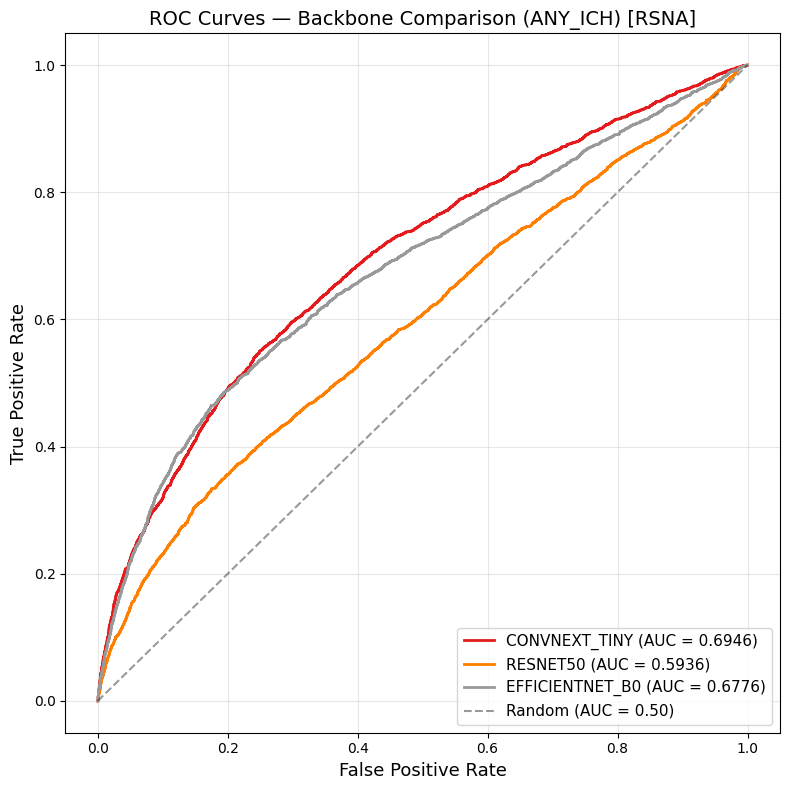

In [16]:
# ============================================================
# Combined ROC Curves — All Backbones Overlaid (RSNA)
# ============================================================
colors = plt.cm.Set1(np.linspace(0, 1, len(BACKBONE_NAMES)))

plt.figure(figsize=(8, 8))

for i, bb_name in enumerate(BACKBONE_NAMES):
    m = all_test_metrics[bb_name]
    fpr, tpr, _ = roc_curve(m["y_true"], m["y_pred"])
    plt.plot(fpr, tpr, color=colors[i], linewidth=2,
             label=f"{bb_name.upper()} (AUC = {m['auc']:.4f})")

plt.plot([0, 1], [0, 1], "k--", alpha=0.4, label="Random (AUC = 0.50)")
plt.xlabel("False Positive Rate", fontsize=13)
plt.ylabel("True Positive Rate", fontsize=13)
plt.title(f"ROC Curves — Backbone Comparison ({EXPERIMENT_NAME.upper()}) [RSNA]", fontsize=14)
plt.legend(loc="lower right", fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 15. Confusion Matrix — Semua Backbone

Confusion matrix masing-masing backbone pada data test RSNA.

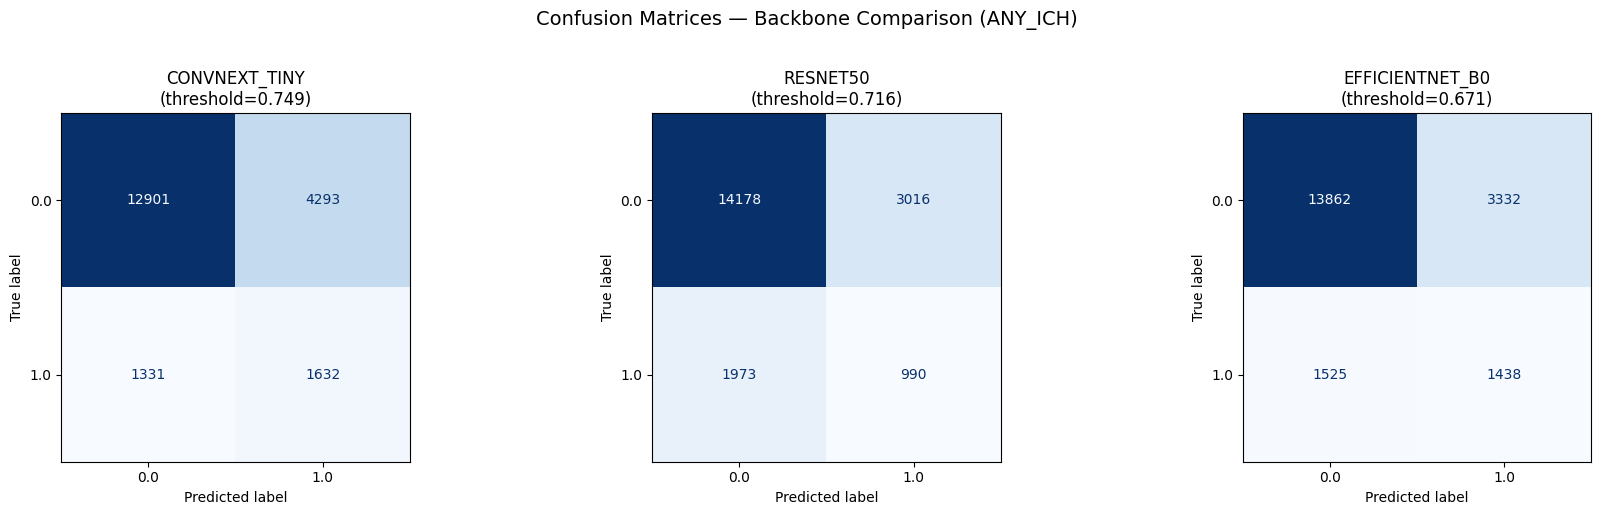

In [17]:
# ============================================================
# Confusion Matrices — All Backbones
# ============================================================
from sklearn.metrics import ConfusionMatrixDisplay

n_cols = min(3, len(BACKBONE_NAMES))
n_rows = int(np.ceil(len(BACKBONE_NAMES) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 5 * n_rows))
axes = np.array(axes).flatten()

for i, bb_name in enumerate(BACKBONE_NAMES):
    m = all_test_metrics[bb_name]
    threshold = m["threshold"]
    y_pred_binary = (m["y_pred"] >= threshold).astype(int)
    
    ConfusionMatrixDisplay.from_predictions(
        m["y_true"], y_pred_binary, ax=axes[i],
        cmap="Blues", colorbar=False
    )
    axes[i].set_title(f"{bb_name.upper()}\n(threshold={threshold:.3f})", fontsize=12)

for j in range(len(BACKBONE_NAMES), len(axes)):
    axes[j].axis("off")

plt.suptitle(f"Confusion Matrices — Backbone Comparison ({EXPERIMENT_NAME.upper()})", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 16. Tabel Ringkasan Metrik

Tabel ringkasan AUC, sensitivitas, spesifisitas, akurasi, dan threshold optimal untuk semua backbone.

In [18]:
# ============================================================
# Summary Metrics Table — All Backbones (RSNA)
# ============================================================
rows = []
for bb_name in BACKBONE_NAMES:
    m = all_test_metrics[bb_name]
    rows.append({
        "Backbone": bb_name.upper(),
        "AUC": f"{m['auc']:.4f}",
        "Sensitivity": f"{m['sensitivity']:.4f}",
        "Specificity": f"{m['specificity']:.4f}",
        "PPV": f"{m['ppv']:.4f}",
        "NPV": f"{m['npv']:.4f}",
        "Accuracy": f"{m['accuracy']:.4f}",
        "Threshold": f"{m['threshold']:.4f}",
    })

df_summary = pd.DataFrame(rows)
print("=" * 90)
print(f"  TEST SET RESULTS — Backbone Comparison ({EXPERIMENT_NAME.upper()}) [RSNA Dataset]")
print("=" * 90)
display(df_summary.style.set_properties(**{
    'text-align': 'center',
    'font-size': '12px'
}).set_table_styles([
    {'selector': 'th', 'props': [('text-align', 'center'), ('font-weight', 'bold')]}
]))

  TEST SET RESULTS — Backbone Comparison (ANY_ICH) [RSNA Dataset]


,Backbone,AUC,Sensitivity,Specificity,PPV,NPV,Accuracy,Threshold
0,CONVNEXT_TINY,0.6946,0.5508,0.7503,0.2754,0.9065,0.7210,0.7485
1,RESNET50,0.5936,0.3341,0.8246,0.2471,0.8778,0.7525,0.7156
2,EFFICIENTNET_B0,0.6776,0.4853,0.8062,0.3015,0.9009,0.7590,0.6715


## 17. Bar Chart AUC

Diagram batang perbandingan AUC antar backbone pada dataset RSNA.

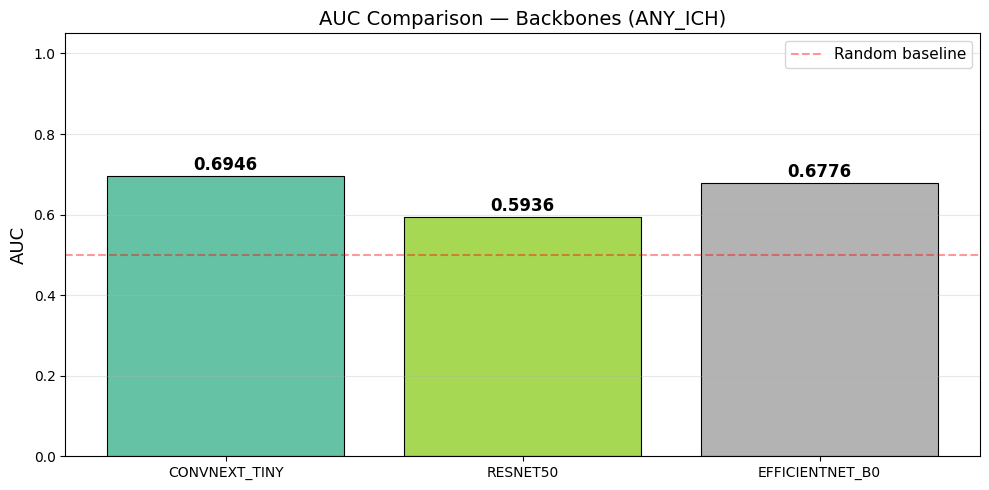

In [19]:
# ============================================================
# AUC Bar Chart Comparison — All Backbones
# ============================================================
auc_values = [all_test_metrics[b]["auc"] for b in BACKBONE_NAMES]
bb_labels = [b.upper() for b in BACKBONE_NAMES]
bar_colors = plt.cm.Set2(np.linspace(0, 1, len(BACKBONE_NAMES)))

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(bb_labels, auc_values, color=bar_colors, edgecolor="black", linewidth=0.8)

for bar, val in zip(bars, auc_values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
            f"{val:.4f}", ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_ylim(0, 1.05)
ax.set_ylabel("AUC", fontsize=13)
ax.set_title(f"AUC Comparison — Backbones ({EXPERIMENT_NAME.upper()})", fontsize=14)
ax.axhline(y=0.5, color="red", linestyle="--", alpha=0.4, label="Random baseline")
ax.legend(fontsize=11)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## 18. Precision-Recall Curve

Kurva Precision-Recall gabungan semua backbone pada dataset RSNA.

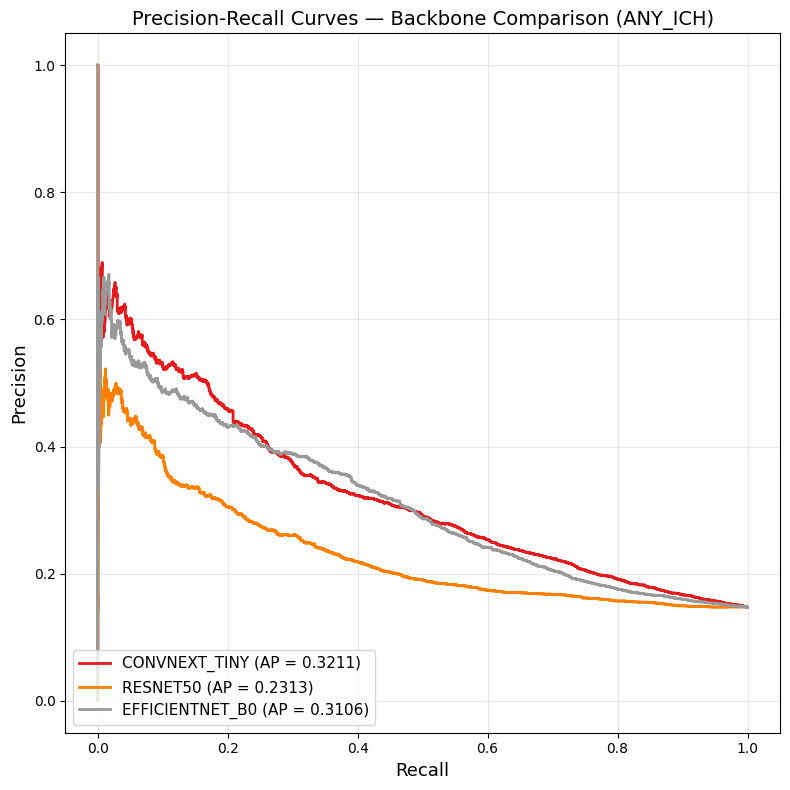

In [20]:
# ============================================================
# Combined Precision-Recall Curves — All Backbones
# ============================================================
colors_pr = plt.cm.Set1(np.linspace(0, 1, len(BACKBONE_NAMES)))

plt.figure(figsize=(8, 8))

for i, bb_name in enumerate(BACKBONE_NAMES):
    m = all_test_metrics[bb_name]
    precision, recall, _ = precision_recall_curve(m["y_true"], m["y_pred"])
    ap = average_precision_score(m["y_true"], m["y_pred"])
    plt.plot(recall, precision, color=colors_pr[i], linewidth=2,
             label=f"{bb_name.upper()} (AP = {ap:.4f})")

plt.xlabel("Recall", fontsize=13)
plt.ylabel("Precision", fontsize=13)
plt.title(f"Precision-Recall Curves — Backbone Comparison ({EXPERIMENT_NAME.upper()})", fontsize=14)
plt.legend(loc="lower left", fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Fig. 1 — Distribusi Kelas Dataset RSNA

Visualisasi jumlah studi positif vs negatif per split (train/val/test) pada level studi/pasien.

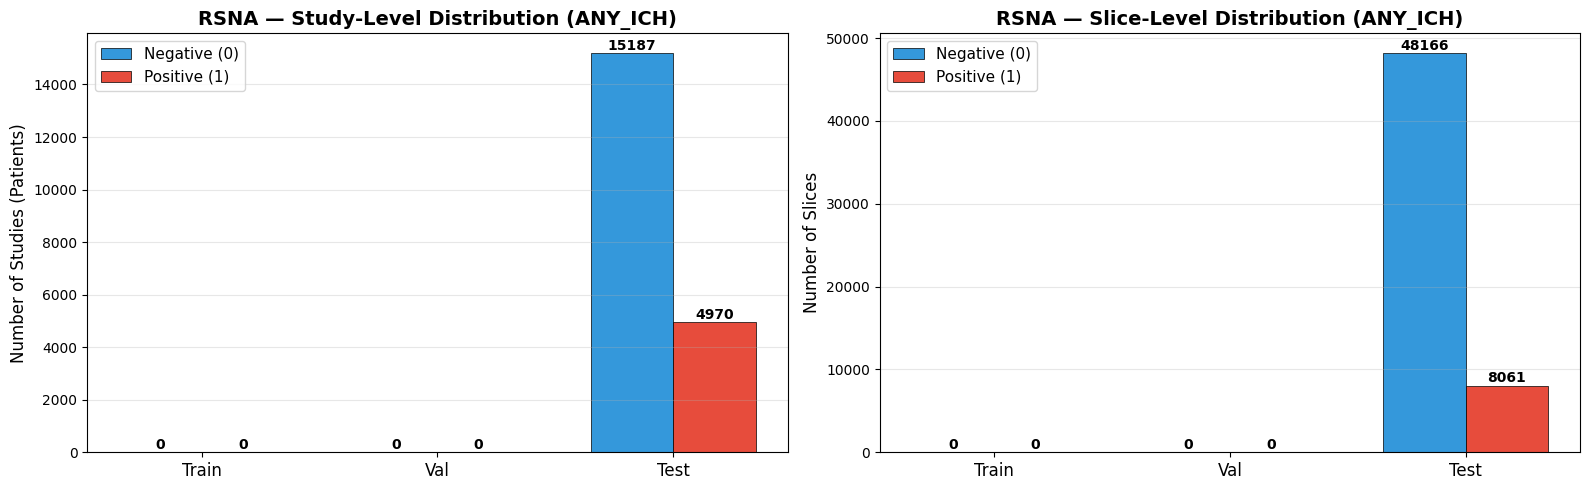

In [21]:
# ============================================================
# Fig. 1 — Dataset Class Distribution (Study-Level) — RSNA
# Shows patient/study counts (not slices) to match CQ500 methodology
# ============================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

subsets = ["train", "val", "test"]

# Study-level counts
pos_studies = []
neg_studies = []
for s in subsets:
    df_s = splits[EXPERIMENT_NAME][s]
    study_labels_s = df_s.groupby("study_id")["label"].max()
    pos_studies.append(int(study_labels_s.sum()))
    neg_studies.append(int(len(study_labels_s) - study_labels_s.sum()))

x = np.arange(len(subsets))
w = 0.35
bars_neg = ax1.bar(x - w/2, neg_studies, w, label="Negative (0)", color="#3498db", edgecolor="black", linewidth=0.5)
bars_pos = ax1.bar(x + w/2, pos_studies, w, label="Positive (1)", color="#e74c3c", edgecolor="black", linewidth=0.5)

for bar in bars_neg:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            str(int(bar.get_height())), ha='center', va='bottom', fontsize=10, fontweight='bold')
for bar in bars_pos:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            str(int(bar.get_height())), ha='center', va='bottom', fontsize=10, fontweight='bold')

ax1.set_xticks(x)
ax1.set_xticklabels(["Train", "Val", "Test"], fontsize=12)
ax1.set_ylabel("Number of Studies (Patients)", fontsize=12)
ax1.set_title(f"RSNA — Study-Level Distribution ({EXPERIMENT_NAME.upper()})", fontsize=14, fontweight="bold")
ax1.legend(fontsize=11)
ax1.grid(axis="y", alpha=0.3)

# Slice-level counts
pos_slices = []
neg_slices = []
for s in subsets:
    df_s = splits[EXPERIMENT_NAME][s]
    pos_slices.append(int(df_s["label"].sum()))
    neg_slices.append(int(len(df_s) - df_s["label"].sum()))

bars_neg2 = ax2.bar(x - w/2, neg_slices, w, label="Negative (0)", color="#3498db", edgecolor="black", linewidth=0.5)
bars_pos2 = ax2.bar(x + w/2, pos_slices, w, label="Positive (1)", color="#e74c3c", edgecolor="black", linewidth=0.5)

for bar in bars_neg2:
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            str(int(bar.get_height())), ha='center', va='bottom', fontsize=10, fontweight='bold')
for bar in bars_pos2:
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            str(int(bar.get_height())), ha='center', va='bottom', fontsize=10, fontweight='bold')

ax2.set_xticks(x)
ax2.set_xticklabels(["Train", "Val", "Test"], fontsize=12)
ax2.set_ylabel("Number of Slices", fontsize=12)
ax2.set_title(f"RSNA — Slice-Level Distribution ({EXPERIMENT_NAME.upper()})", fontsize=14, fontweight="bold")
ax2.legend(fontsize=11)
ax2.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## Fig. 4 — Trade-off Sensitivitas vs Spesifisitas

Scatter plot posisi tiap backbone pada ruang sensitivitas-spesifisitas.

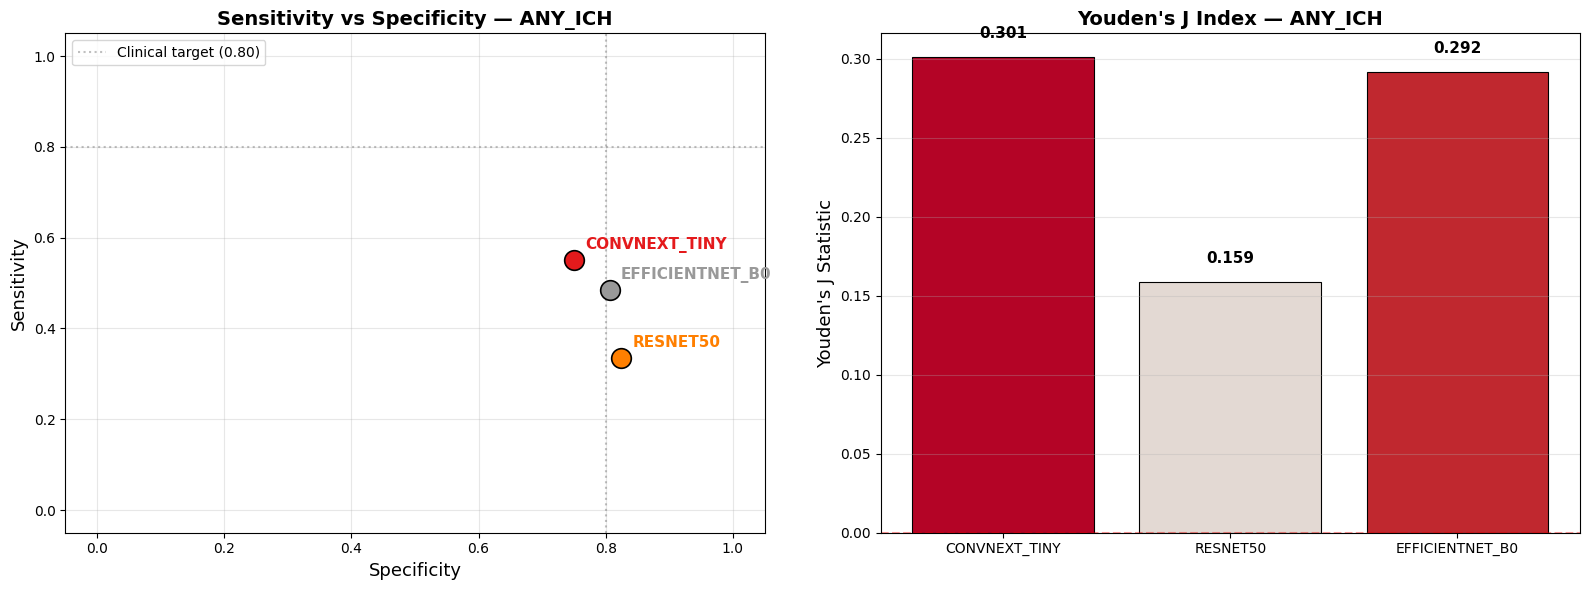

In [22]:
# ============================================================
# Fig. 4 — Sensitivity vs Specificity Trade-off Scatter
# ============================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

scatter_colors = plt.cm.Set1(np.linspace(0, 1, len(BACKBONE_NAMES)))

for i, bb_name in enumerate(BACKBONE_NAMES):
    m = all_test_metrics[bb_name]
    ax1.scatter(m["specificity"], m["sensitivity"], color=scatter_colors[i],
                s=200, edgecolor="black", linewidth=1.2, zorder=5)
    ax1.annotate(bb_name.upper(),
                 (m["specificity"], m["sensitivity"]),
                 textcoords="offset points", xytext=(8, 8),
                 fontsize=11, fontweight="bold", color=scatter_colors[i])

ax1.set_xlabel("Specificity", fontsize=13)
ax1.set_ylabel("Sensitivity", fontsize=13)
ax1.set_title(f"Sensitivity vs Specificity — {EXPERIMENT_NAME.upper()}", fontsize=14, fontweight="bold")
ax1.set_xlim(-0.05, 1.05)
ax1.set_ylim(-0.05, 1.05)
ax1.axhline(y=0.8, color="gray", linestyle=":", alpha=0.5, label="Clinical target (0.80)")
ax1.axvline(x=0.8, color="gray", linestyle=":", alpha=0.5)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# ============================================================
# Fig. 5 — Youden's J Statistic
# ============================================================
youden_values = []
for bb_name in BACKBONE_NAMES:
    m = all_test_metrics[bb_name]
    j_stat = m["sensitivity"] + m["specificity"] - 1
    youden_values.append(j_stat)

bar_colors_j = plt.cm.coolwarm(np.array(youden_values) / max(max(youden_values), 0.01))
bars = ax2.bar([b.upper() for b in BACKBONE_NAMES], youden_values,
               color=bar_colors_j, edgecolor="black", linewidth=0.8)

for bar, val in zip(bars, youden_values):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
             f"{val:.3f}", ha='center', va='bottom', fontsize=11, fontweight='bold')

ax2.set_ylabel("Youden's J Statistic", fontsize=13)
ax2.set_title(f"Youden's J Index — {EXPERIMENT_NAME.upper()}", fontsize=14, fontweight="bold")
ax2.axhline(y=0, color="red", linestyle="--", alpha=0.4)
ax2.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## Fig. 7 — AUC dengan Confidence Interval 95%

AUC beserta interval kepercayaan 95% menggunakan bootstrap resampling (1000 iterasi).

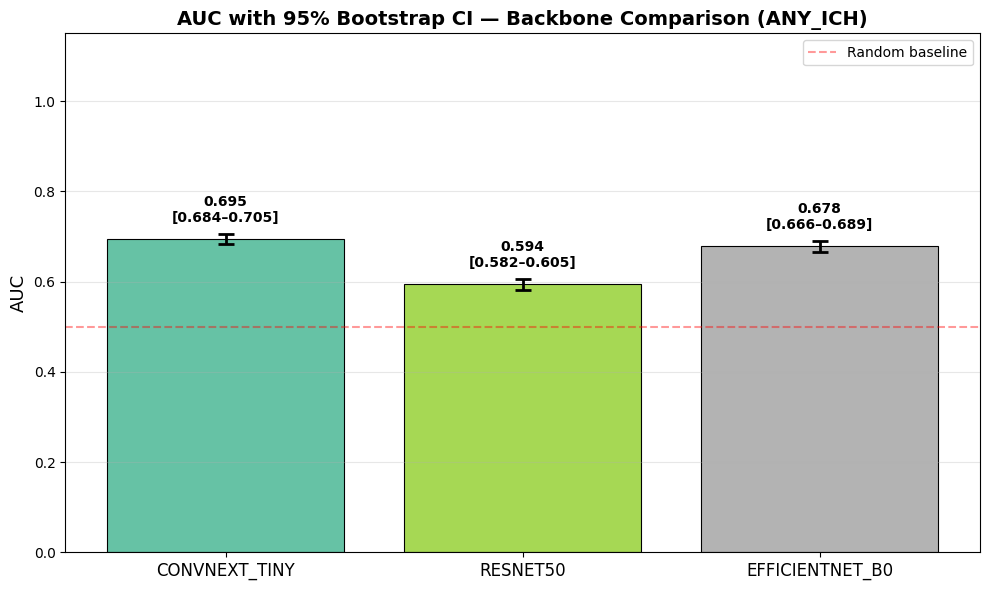


  AUC with 95% Bootstrap CI — ANY_ICH
       CONVNEXT_TINY  |  AUC: 0.6949  (95% CI: 0.6841 – 0.7050)
            RESNET50  |  AUC: 0.5937  (95% CI: 0.5817 – 0.6050)
     EFFICIENTNET_B0  |  AUC: 0.6777  (95% CI: 0.6661 – 0.6889)


In [23]:
# ============================================================
# Fig. 7 — AUC with 95% Confidence Intervals (Bootstrap) per Backbone
# ============================================================
from sklearn.utils import resample

def bootstrap_auc(y_true, y_pred, n_bootstraps=1000, seed=42):
    """Compute AUC with 95% CI using bootstrap resampling."""
    rng = np.random.RandomState(seed)
    aucs = []
    for _ in range(n_bootstraps):
        idx = rng.randint(0, len(y_true), len(y_true))
        y_t = y_true[idx]
        y_p = y_pred[idx]
        if len(np.unique(y_t)) < 2:
            continue
        aucs.append(roc_auc_score(y_t, y_p))
    aucs = np.array(aucs)
    return np.mean(aucs), np.percentile(aucs, 2.5), np.percentile(aucs, 97.5)

# Compute CIs
ci_results = {}
for bb_name in BACKBONE_NAMES:
    m = all_test_metrics[bb_name]
    mean_auc, ci_low, ci_high = bootstrap_auc(m["y_true"], m["y_pred"])
    ci_results[bb_name] = {"mean": mean_auc, "ci_low": ci_low, "ci_high": ci_high}

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(BACKBONE_NAMES))
means = [ci_results[b]["mean"] for b in BACKBONE_NAMES]
ci_lows = [ci_results[b]["ci_low"] for b in BACKBONE_NAMES]
ci_highs = [ci_results[b]["ci_high"] for b in BACKBONE_NAMES]
errors = [[m - lo for m, lo in zip(means, ci_lows)],
          [hi - m for m, hi in zip(means, ci_highs)]]

bar_colors = plt.cm.Set2(np.linspace(0, 1, len(BACKBONE_NAMES)))
bars = ax.bar(x, means, color=bar_colors, edgecolor="black", linewidth=0.8, yerr=errors,
              capsize=6, error_kw=dict(lw=2, capthick=2))

for xi, m, lo, hi in zip(x, means, ci_lows, ci_highs):
    ax.text(xi, hi + 0.02, f"{m:.3f}\n[{lo:.3f}–{hi:.3f}]",
            ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels([b.upper() for b in BACKBONE_NAMES], fontsize=12)
ax.set_ylabel("AUC", fontsize=13)
ax.set_title(f"AUC with 95% Bootstrap CI — Backbone Comparison ({EXPERIMENT_NAME.upper()})", fontsize=14, fontweight="bold")
ax.set_ylim(0, 1.15)
ax.axhline(y=0.5, color="red", linestyle="--", alpha=0.4, label="Random baseline")
ax.legend(fontsize=10)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# Print CI table
print("\n" + "=" * 65)
print(f"  AUC with 95% Bootstrap CI — {EXPERIMENT_NAME.upper()}")
print("=" * 65)
for bb_name in BACKBONE_NAMES:
    r = ci_results[bb_name]
    print(f"  {bb_name.upper():>18s}  |  AUC: {r['mean']:.4f}  "
          f"(95% CI: {r['ci_low']:.4f} – {r['ci_high']:.4f})")
print("=" * 65)

## Fig. 8 — F1-Score & Balanced Accuracy

Perbandingan F1-score dan balanced accuracy per backbone pada threshold optimal.

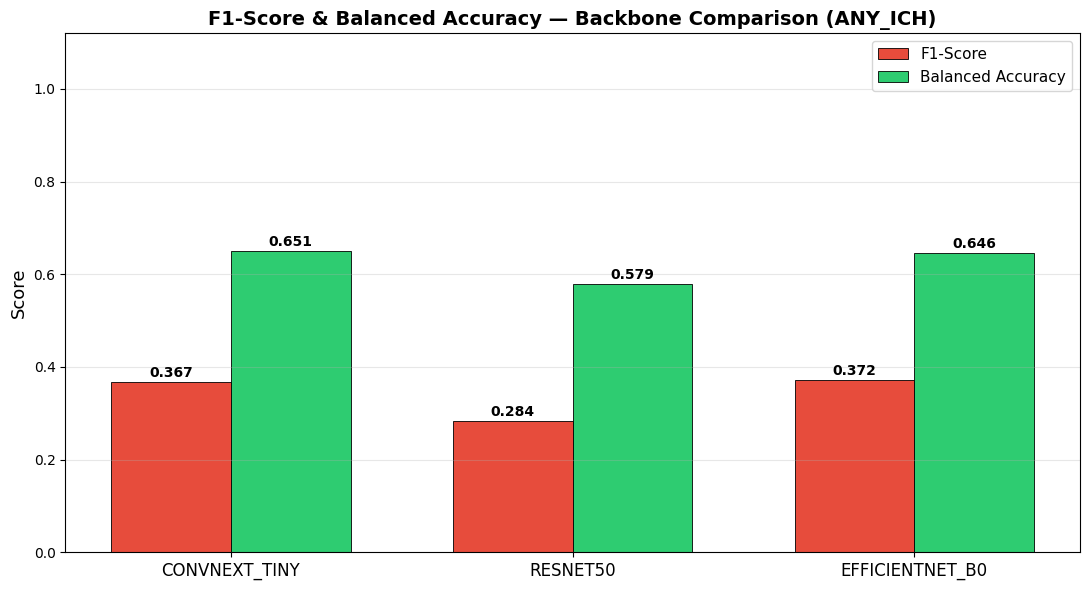

In [24]:
# ============================================================
# Fig. 8 — F1-Score & Balanced Accuracy Comparison per Backbone
# ============================================================
from sklearn.metrics import f1_score, balanced_accuracy_score

f1_values = []
bal_acc_values = []

for bb_name in BACKBONE_NAMES:
    m = all_test_metrics[bb_name]
    y_bin = (m["y_pred"] >= m["threshold"]).astype(int)
    f1_values.append(f1_score(m["y_true"], y_bin))
    bal_acc_values.append(balanced_accuracy_score(m["y_true"], y_bin))

x = np.arange(len(BACKBONE_NAMES))
w = 0.35

fig, ax = plt.subplots(figsize=(11, 6))
bars1 = ax.bar(x - w/2, f1_values, w, label="F1-Score", color="#e74c3c", edgecolor="black", linewidth=0.6)
bars2 = ax.bar(x + w/2, bal_acc_values, w, label="Balanced Accuracy", color="#2ecc71", edgecolor="black", linewidth=0.6)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{bar.get_height():.3f}", ha='center', fontsize=10, fontweight='bold')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{bar.get_height():.3f}", ha='center', fontsize=10, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels([b.upper() for b in BACKBONE_NAMES], fontsize=12)
ax.set_ylabel("Score", fontsize=13)
ax.set_title(f"F1-Score & Balanced Accuracy — Backbone Comparison ({EXPERIMENT_NAME.upper()})", fontsize=14, fontweight="bold")
ax.set_ylim(0, 1.12)
ax.legend(fontsize=11)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## Fig. 10 — Analisis Threshold

Plot sensitivitas dan spesifisitas sebagai fungsi threshold untuk masing-masing backbone.

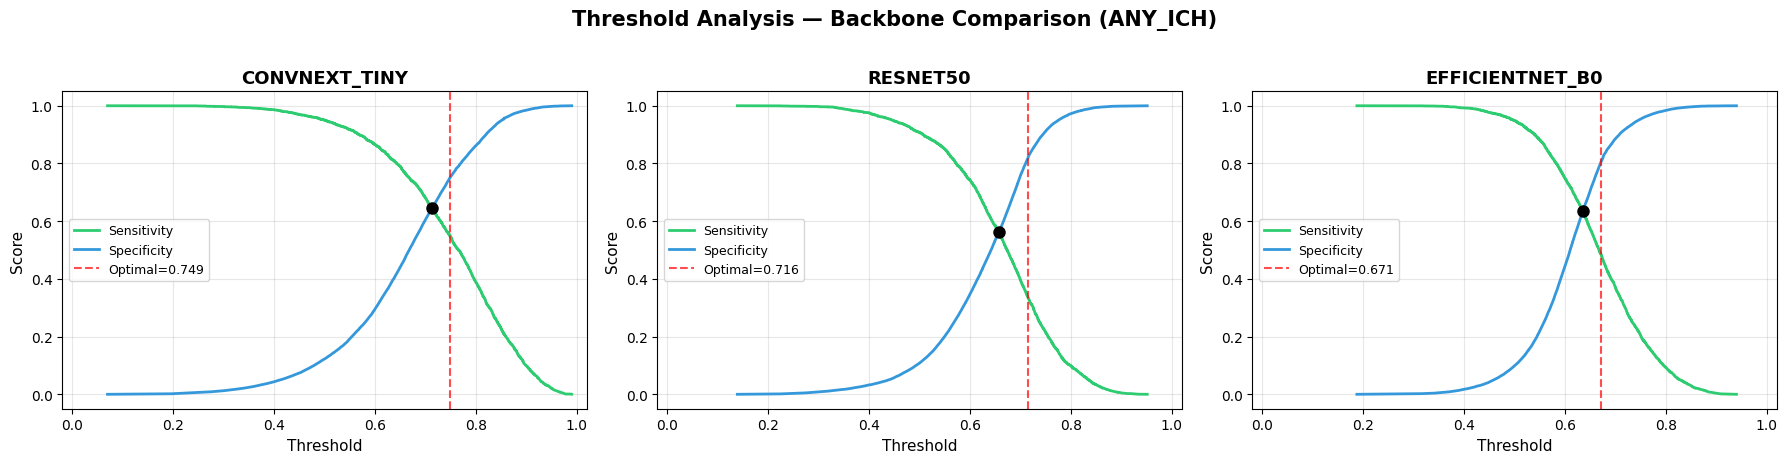

In [25]:
# ============================================================
# Fig. 10 — Threshold vs Sensitivity/Specificity (Per Backbone)
# ============================================================
n_cols = min(3, len(BACKBONE_NAMES))
n_rows = int(np.ceil(len(BACKBONE_NAMES) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4.5 * n_rows))
axes = np.array(axes).flatten()

for i, bb_name in enumerate(BACKBONE_NAMES):
    m = all_test_metrics[bb_name]
    fpr, tpr, thresholds = roc_curve(m["y_true"], m["y_pred"])
    sens = tpr
    spec = 1 - fpr
    
    axes[i].plot(thresholds, sens, color="#2ecc71", linewidth=2, label="Sensitivity")
    axes[i].plot(thresholds, spec, color="#3498db", linewidth=2, label="Specificity")
    
    axes[i].axvline(x=m["threshold"], color="red", linestyle="--", alpha=0.7,
                     label=f"Optimal={m['threshold']:.3f}")
    
    diff = np.abs(sens - spec)
    cross_idx = np.argmin(diff)
    axes[i].plot(thresholds[cross_idx], sens[cross_idx], 'ko', markersize=8)
    
    axes[i].set_xlabel("Threshold", fontsize=11)
    axes[i].set_ylabel("Score", fontsize=11)
    axes[i].set_title(f"{bb_name.upper()}", fontsize=13, fontweight="bold")
    axes[i].legend(fontsize=9, loc="center left")
    axes[i].grid(True, alpha=0.3)
    axes[i].set_xlim(-0.02, 1.02)

for j in range(len(BACKBONE_NAMES), len(axes)):
    axes[j].axis("off")

fig.suptitle(f"Threshold Analysis — Backbone Comparison ({EXPERIMENT_NAME.upper()})", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## Table 1 — Laporan Akademik Lengkap

Tabel komprehensif dengan AUC ± 95% CI, sensitivitas, spesifisitas, F1, balanced accuracy, dan MCC untuk semua backbone.

In [26]:
# ============================================================
# Table 1 — Full Academic Report Table (with 95% CI for AUC)
# ============================================================
from sklearn.metrics import f1_score, balanced_accuracy_score, matthews_corrcoef

report_rows = []
for bb_name in BACKBONE_NAMES:
    m = all_test_metrics[bb_name]
    ci = ci_results[bb_name]
    y_bin = (m["y_pred"] >= m["threshold"]).astype(int)
    
    f1 = f1_score(m["y_true"], y_bin)
    bal_acc = balanced_accuracy_score(m["y_true"], y_bin)
    mcc = matthews_corrcoef(m["y_true"], y_bin)
    ap = average_precision_score(m["y_true"], m["y_pred"])
    
    j_stat = m["sensitivity"] + m["specificity"] - 1
    
    report_rows.append({
        "Backbone": bb_name.upper(),
        "AUC": f"{ci['mean']:.4f}",
        "95% CI": f"[{ci['ci_low']:.4f}–{ci['ci_high']:.4f}]",
        "Sens": f"{m['sensitivity']:.4f}",
        "Spec": f"{m['specificity']:.4f}",
        "PPV": f"{m['ppv']:.4f}",
        "NPV": f"{m['npv']:.4f}",
        "F1": f"{f1:.4f}",
        "Bal Acc": f"{bal_acc:.4f}",
        "MCC": f"{mcc:.4f}",
        "AP": f"{ap:.4f}",
        "Youden J": f"{j_stat:.4f}",
    })

df_report = pd.DataFrame(report_rows)

print("=" * 120)
print(f"  TABLE 1: Complete Performance Metrics — Backbone Comparison ({EXPERIMENT_NAME.upper()})")
print("=" * 120)
display(df_report.style.set_properties(**{
    'text-align': 'center', 'font-size': '11px'
}).set_table_styles([
    {'selector': 'th', 'props': [('text-align', 'center'), ('font-weight', 'bold'), ('font-size', '11px')]}
]))

  TABLE 1: Complete Performance Metrics — Backbone Comparison (ANY_ICH)


,Backbone,AUC,95% CI,Sens,Spec,PPV,NPV,F1,Bal Acc,MCC,AP,Youden J
0,CONVNEXT_TINY,0.6949,[0.6841–0.7050],0.5508,0.7503,0.2754,0.9065,0.3672,0.6506,0.2340,0.3211,0.3011
1,RESNET50,0.5937,[0.5817–0.6050],0.3341,0.8246,0.2471,0.8778,0.2841,0.5794,0.1408,0.2313,0.1587
2,EFFICIENTNET_B0,0.6777,[0.6661–0.6889],0.4853,0.8062,0.3015,0.9009,0.3719,0.6458,0.2429,0.3106,0.2915


## Fig. 14 — AUPRC (Area Under Precision-Recall Curve)

Perbandingan AUPRC antar backbone pada dataset RSNA.

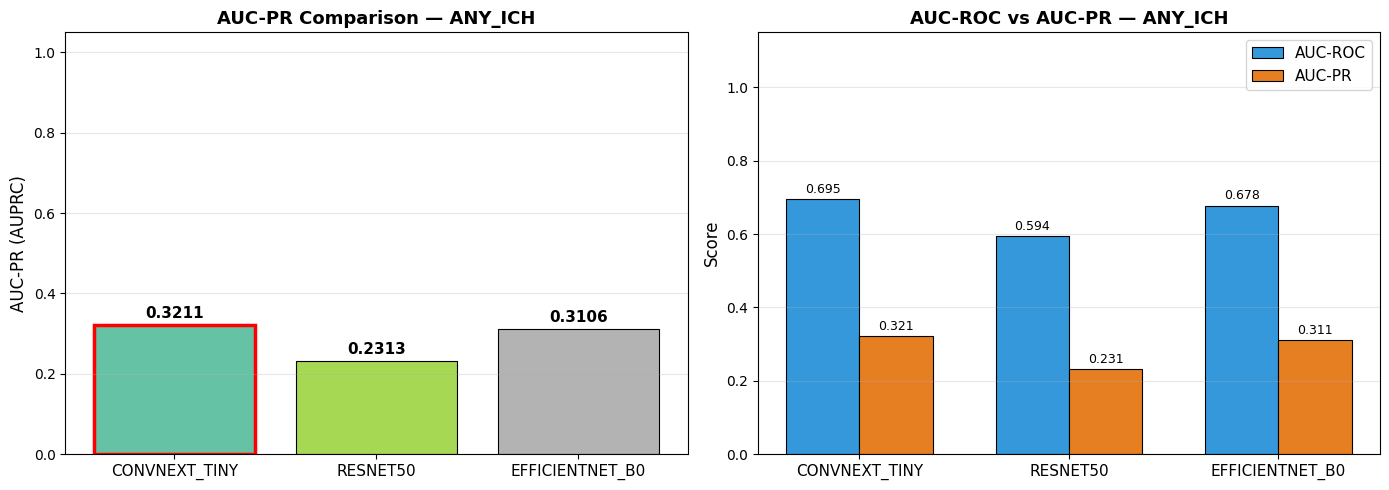


  AUC-PR (AUPRC) Results — ANY_ICH
  CONVNEXT_TINY         AUC-PR = 0.3211
  RESNET50              AUC-PR = 0.2313
  EFFICIENTNET_B0       AUC-PR = 0.3106


In [27]:
# ==============================================================
# Fig. 14 — AUC-PR (AUPRC) Comparison per Backbone
# ==============================================================
from sklearn.metrics import average_precision_score, precision_recall_curve

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: Bar chart of AUPRC ---
auprc_vals = {}
for bb_name in BACKBONE_NAMES:
    m = all_test_metrics[bb_name]
    auprc_vals[bb_name] = average_precision_score(m["y_true"], m["y_pred"])

colors = plt.cm.Set2(np.linspace(0, 1, len(BACKBONE_NAMES)))
bars = axes[0].bar(range(len(BACKBONE_NAMES)),
                   [auprc_vals[b] for b in BACKBONE_NAMES],
                   color=colors, edgecolor='black', linewidth=0.8)
axes[0].set_xticks(range(len(BACKBONE_NAMES)))
axes[0].set_xticklabels([b.upper() for b in BACKBONE_NAMES], fontsize=11)
axes[0].set_ylabel("AUC-PR (AUPRC)", fontsize=12)
axes[0].set_title(f"AUC-PR Comparison — {EXPERIMENT_NAME.upper()}", fontsize=13, fontweight="bold")
axes[0].set_ylim(0, 1.05)
axes[0].grid(True, alpha=0.3, axis='y')

for bar, bb_name in zip(bars, BACKBONE_NAMES):
    val = auprc_vals[bb_name]
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                 f"{val:.4f}", ha='center', va='bottom', fontsize=11, fontweight='bold')

# Highlight the best
best_bb = max(auprc_vals, key=auprc_vals.get)
best_idx = BACKBONE_NAMES.index(best_bb)
bars[best_idx].set_edgecolor('red')
bars[best_idx].set_linewidth(2.5)

# --- Right: AUC-ROC vs AUC-PR side-by-side ---
x = np.arange(len(BACKBONE_NAMES))
width = 0.35

auc_roc_vals = [all_test_metrics[b]["auc"] if "auc" in all_test_metrics[b]
                else roc_auc_score(all_test_metrics[b]["y_true"], all_test_metrics[b]["y_pred"])
                for b in BACKBONE_NAMES]
auc_pr_vals = [auprc_vals[b] for b in BACKBONE_NAMES]

rects1 = axes[1].bar(x - width/2, auc_roc_vals, width, label='AUC-ROC', color='#3498db', edgecolor='black', linewidth=0.8)
rects2 = axes[1].bar(x + width/2, auc_pr_vals, width, label='AUC-PR', color='#e67e22', edgecolor='black', linewidth=0.8)

axes[1].set_xticks(x)
axes[1].set_xticklabels([b.upper() for b in BACKBONE_NAMES], fontsize=11)
axes[1].set_ylabel("Score", fontsize=12)
axes[1].set_title(f"AUC-ROC vs AUC-PR — {EXPERIMENT_NAME.upper()}", fontsize=13, fontweight="bold")
axes[1].set_ylim(0, 1.15)
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3, axis='y')

for rect in rects1:
    axes[1].text(rect.get_x() + rect.get_width()/2, rect.get_height() + 0.01,
                 f"{rect.get_height():.3f}", ha='center', va='bottom', fontsize=9)
for rect in rects2:
    axes[1].text(rect.get_x() + rect.get_width()/2, rect.get_height() + 0.01,
                 f"{rect.get_height():.3f}", ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print(f"\n{'='*60}")
print(f"  AUC-PR (AUPRC) Results — {EXPERIMENT_NAME.upper()}")
print(f"{'='*60}")
for bb_name in BACKBONE_NAMES:
    print(f"  {bb_name.upper():20s}  AUC-PR = {auprc_vals[bb_name]:.4f}")
print(f"{'='*60}")

## Table 3 — Uji McNemar (Signifikansi Statistik)

Uji statistik berpasangan (McNemar's test) untuk menilai apakah perbedaan performa antar backbone signifikan secara statistik.

In [28]:
# ============================================================
# Table 3 — Pairwise McNemar's Test (Statistical Significance between Backbones)
# ============================================================
from itertools import combinations

# Build binary prediction arrays at optimal thresholds
binary_preds = {}
for bb_name in BACKBONE_NAMES:
    m = all_test_metrics[bb_name]
    y_true = np.array(m["y_true"])
    y_prob = np.array(m["y_pred"])
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    j_scores = tpr - fpr
    opt_idx = np.argmax(j_scores)
    opt_thresh = thresholds[opt_idx]
    binary_preds[bb_name] = (y_prob >= opt_thresh).astype(int)

# Pairwise McNemar's
mcnemar_rows = []
for (a, b) in combinations(BACKBONE_NAMES, 2):
    y_true_a = np.array(all_test_metrics[a]["y_true"])
    pred_a = binary_preds[a]
    pred_b = binary_preds[b]
    
    n01 = np.sum((pred_a == y_true_a) & (pred_b != y_true_a))
    n10 = np.sum((pred_a != y_true_a) & (pred_b == y_true_a))
    
    if n01 + n10 > 0:
        chi2 = (abs(n01 - n10) - 1) ** 2 / (n01 + n10)
        from scipy.stats import chi2 as chi2_dist
        p_val = 1 - chi2_dist.cdf(chi2, df=1)
    else:
        chi2 = 0.0
        p_val = 1.0
    
    sig = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else "ns"
    mcnemar_rows.append({
        "Comparison": f"{a.upper()} vs {b.upper()}",
        "n_01 (A✓B✗)": int(n01),
        "n_10 (A✗B✓)": int(n10),
        "χ²": f"{chi2:.3f}",
        "p-value": f"{p_val:.4f}" if p_val >= 0.0001 else f"{p_val:.2e}",
        "Significance": sig
    })

df_mcnemar = pd.DataFrame(mcnemar_rows)
print("\n" + "=" * 100)
print(f"  TABLE 3: Pairwise McNemar's Test — Backbone Comparison ({EXPERIMENT_NAME.upper()})")
print("  (*** p<0.001, ** p<0.01, * p<0.05, ns = not significant)")
print("=" * 100)
display(df_mcnemar.style.set_properties(**{
    'text-align': 'center', 'font-size': '11px'
}).set_table_styles([
    {'selector': 'th', 'props': [('text-align', 'center'), ('font-weight', 'bold')]}
]))


  TABLE 3: Pairwise McNemar's Test — Backbone Comparison (ANY_ICH)
  (*** p<0.001, ** p<0.01, * p<0.05, ns = not significant)


,Comparison,n_01 (A✓B✗),n_10 (A✗B✓),χ²,p-value,Significance
0,CONVNEXT_TINY vs RESNET50,2279,2914,77.403,0.00e+00,***
1,CONVNEXT_TINY vs EFFICIENTNET_B0,1826,2593,132.780,0.00e+00,***
2,RESNET50 vs EFFICIENTNET_B0,2096,2228,3.969,0.0464,*
